In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

We load clean data

In [3]:
try:
    df = pd.read_csv("../Data/Processed/clean_data_encoded.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/selomrani/EduPredict/refs/heads/main/Data/Processed/clean_data_encoded.csv")

X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

Split into train (80%) and test (20%)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train the LinearRegression model and predict

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate with RMSE, MAE and R²

In [6]:
scores = cross_val_score(model, X_train, y_train, cv=5,
                         scoring="neg_root_mean_squared_error")
print("5-fold CV RMSE:", round(-scores.mean(), 2),
      "(+/-", round(scores.std(), 2), ")")

5-fold CV RMSE: 0.33 (+/- 0.0 )


In [7]:
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))
print("R²  :", round(r2_score(y_test, y_pred), 4))

RMSE: 0.33
MAE : 0.27
R²  : 0.9897


Plot actual vs predicted

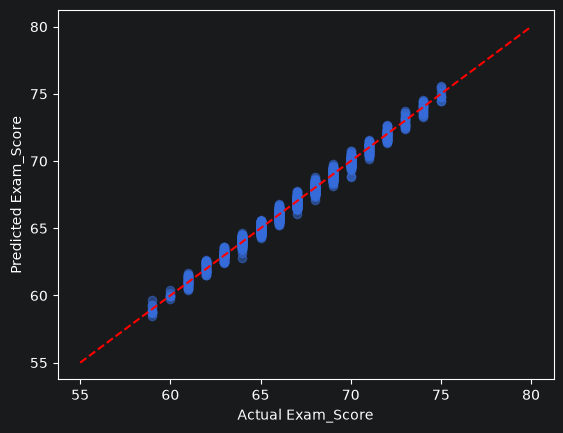

In [8]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([55, 80], [55, 80], "r--")
plt.xlabel("Actual Exam_Score")
plt.ylabel("Predicted Exam_Score")
plt.show()